# LeetCode #88: Merge Sorted Array

https://leetcode.com/problems/merge-sorted-array/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O((m+n)\log(m+n))$ | $O(1)$ |
| **Three Pointers (Merge from End)** ★ | $O(m+n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
Copy nums2 into the trailing zeros of nums1, then sort the entire array. Sorting dominates at $O((m+n)\log(m+n))$ and wastes the fact that both halves are already sorted.

### Optimal: Three Pointers (Merge from End) ★
Place the largest remaining element at the back of nums1, comparing from the ends of both sorted sections (p1 at index m−1, p2 at n−1, write head p at m+n−1). Writing backwards guarantees we never overwrite a nums1 element before we've read it.

**Why this is better than Brute Force:** Exploits both arrays being pre-sorted to merge in one linear pass instead of re-sorting, dropping time from $O((m+n)\log(m+n))$ to $O(m+n)$ with the same $O(1)$ space.

**Constraints:**
* nums1.length == m + n
* nums2.length == n
* 0 ≤ m, n ≤ 200
* −10⁹ ≤ nums1[i], nums2[j] ≤ 10⁹

## Solutions

### C#

In [ ]:
public class Solution {
    public void Merge(int[] nums1, int m, int[] nums2, int n) {
        int p1 = m - 1, p2 = n - 1, p = m + n - 1;
        // Fill from the end so we never overwrite an unread nums1 element
        while (p1 >= 0 && p2 >= 0)
            nums1[p--] = nums1[p1] >= nums2[p2] ? nums1[p1--] : nums2[p2--];
        // Any remaining nums2 elements slot directly into nums1's prefix
        while (p2 >= 0)
            nums1[p--] = nums2[p2--];
    }
}

### Python

In [ ]:
class Solution:
    def merge(self, nums1: List[int], m: int, nums2: List[int], n: int) -> None:
        p1, p2, p = m - 1, n - 1, m + n - 1
        # Fill from the end so we never overwrite an unread nums1 element
        while p1 >= 0 and p2 >= 0:
            if nums1[p1] >= nums2[p2]:
                nums1[p] = nums1[p1]
                p1 -= 1
            else:
                nums1[p] = nums2[p2]
                p2 -= 1
            p -= 1
        # Any remaining nums2 elements slot directly into nums1's prefix
        while p2 >= 0:
            nums1[p] = nums2[p2]
            p -= 1
            p2 -= 1

### Go

In [ ]:
func merge(nums1 []int, m int, nums2 []int, n int) {
    p1, p2, p := m-1, n-1, m+n-1
    // Fill from the end so we never overwrite an unread nums1 element
    for p1 >= 0 && p2 >= 0 {
        if nums1[p1] >= nums2[p2] {
            nums1[p] = nums1[p1]
            p1--
        } else {
            nums1[p] = nums2[p2]
            p2--
        }
        p--
    }
    // Any remaining nums2 elements slot directly into nums1's prefix
    for p2 >= 0 {
        nums1[p] = nums2[p2]
        p--
        p2--
    }
}

### Rust

In [ ]:
pub fn merge(nums1: &mut Vec<i32>, m: i32, nums2: &mut Vec<i32>, n: i32) {
    let (mut p1, mut p2) = (m as i64 - 1, n as i64 - 1);
    let mut p = m as i64 + n as i64 - 1;
    // Fill from the end so we never overwrite an unread nums1 element
    while p1 >= 0 && p2 >= 0 {
        if nums1[p1 as usize] >= nums2[p2 as usize] {
            nums1[p as usize] = nums1[p1 as usize];
            p1 -= 1;
        } else {
            nums1[p as usize] = nums2[p2 as usize];
            p2 -= 1;
        }
        p -= 1;
    }
    // Any remaining nums2 elements slot directly into nums1's prefix
    while p2 >= 0 {
        nums1[p as usize] = nums2[p2 as usize];
        p -= 1;
        p2 -= 1;
    }
}

## Example Scenarios

**1. Common Case**
**Input:** nums1 = [1,2,3,0,0,0] m=3, nums2 = [2,5,6] n=3
Comparisons from the end: 6>3 → place 6; 5>3 → place 5; 3>2 → place 3; 2≥2 → place 2 (nums1's); 2>1 → place nums2's 2; p2<0, loop ends. nums1's 1 is already at index 0. Result: **[1,2,2,3,5,6]**.

**2. Slightly Complex — nums2 exhausted first (nums1 wins every comparison)**
**Input:** nums1 = [4,5,6,0,0,0] m=3, nums2 = [1,2,3] n=3
6>3, 5>2, 4>1 → all three wins go to nums1. p1→−1, loop ends. Remaining p2=0..2 copied in reverse: nums1[2]=3, nums1[1]=2, nums1[0]=1. Result: **[1,2,3,4,5,6]**.

**3. Edge Case: Time Factor — all elements interleave, both pointers stay active the full length**
**Input:** nums1 = [1,3,5,0,0,0] m=3, nums2 = [2,4,6] n=3
Comparisons alternate: 6>5, 5>4, 4>3, 3>2, 2>1 … both p1 and p2 move at each step. Neither pointer finishes early — worst case for comparison count: $m+n−1$ decisions. Result: **[1,2,3,4,5,6]**.

**4. Edge Case: Space Factor — m=0, nothing in nums1 to read**
**Input:** nums1 = [0,0,0] m=0, nums2 = [1,2,3] n=3
p1=−1, so the main while loop never executes. The cleanup loop copies all of nums2 directly into nums1 in one pass. Extra space: $O(1)$ — three integer pointers only. Result: **[1,2,3]**.

**5. Almost-Impossible but Plausible — nums1 element must move to the back to make room**
**Input:** nums1 = [2,0] m=1, nums2 = [1] n=1
p1=0, p2=0, p=1. nums1[0]=2 ≥ nums2[0]=1 → place 2 at index 1, p1→−1. Main loop ends. Cleanup: place nums2[0]=1 at index 0. The write pointer p was always ≥ p1, so no overwrite occurred. Result: **[1,2]**.

## Infographic

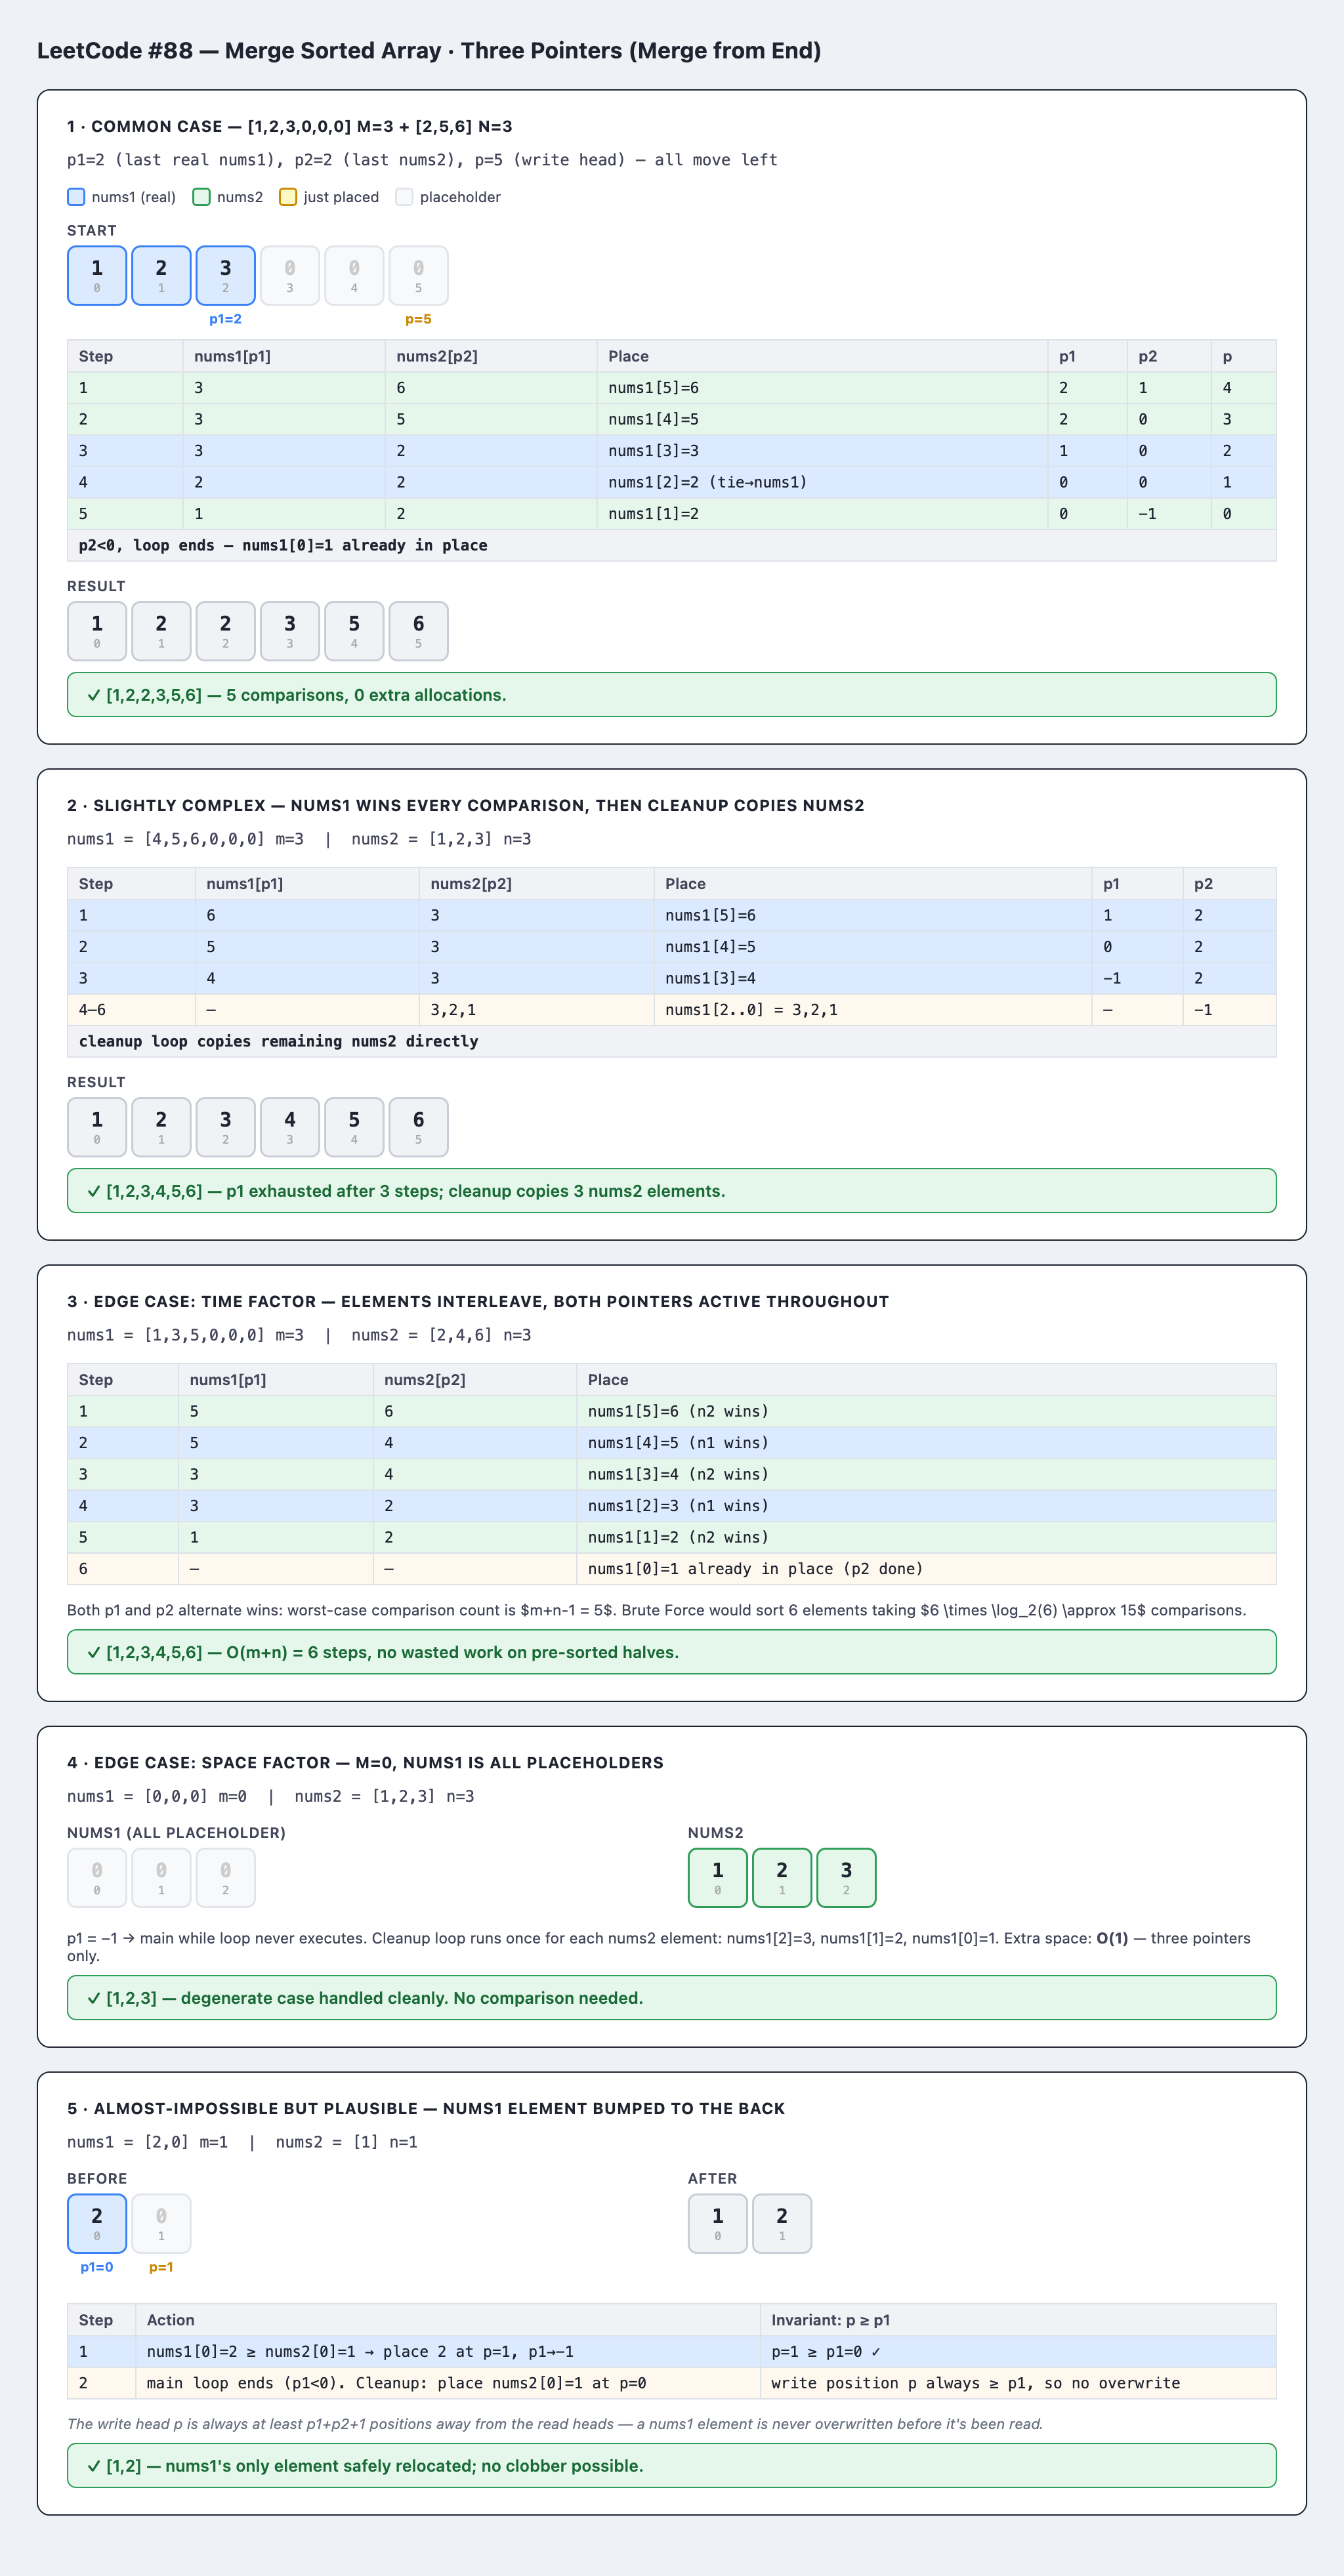